# SIOC 251 – Homework 0 Notebook

## Dark Side Of The Moon Ray Tracing Comparison 

**Name:** Amanda Mallinckrodt  
**Date:** 04/06/26

---


## Problem Statement

Using Snell's law and the given index of refraction formula $$n(\lambda) = A + \frac{B}{\lambda^2}$$ create a simple ray tracing model through a prism with the following wavelengths: 

| Color | Wavelength ($\lambda$ in μm) |
| :--- | :--- | 
| **Violet** | 0.40 |
| **Blue** | 0.45 |
| **Cyan** | 0.50 |
| **Green** | 0.55 |
| **Yellow** | 0.58 | 
| **Orange** | 0.62 | 
| **Red** | 0.70 | 

To determine if Pink Floyd's Dark Side of the Moon cover is physically accurate 

# Model Verification

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.ioff()

# 1. Setup data & cauchy index of refraction 
wavelengths = [0.30, 0.40, 0.45, 0.50, 0.55, 0.58, 0.62, 0.70, 1.0]
colors = ['#4B0082','#8F00FF', '#0000FF', '#00FFFF', '#00FF00', '#FFFF00', '#FF7F00', '#FF0000', '#550000']
names = ["Ultraviolet (Test)","Violet", "Blue", "Cyan", "Green", "Yellow", "Orange", "Red", "Infrared (Test)"]

def get_n(wl):
    return 1.50 + (0.004 / (wl**2))

calculated_rays = []

print(f"{'Color':<10} | {'λ (µm)':<8} | {'n(λ)':<8} | {'Exit Angle'}")
print("-" * 48)

for wl, color, name in zip(wavelengths, colors, names):
    n = get_n(wl)
    
    # Physics Calculations
    theta_i1 = np.radians(30)
    theta_r1 = np.arcsin(np.sin(theta_i1) / n)
    theta_i2 = np.radians(60) - theta_r1
    theta_r2 = np.arcsin(n * np.sin(theta_i2))
    exit_angle_deg = np.degrees(theta_r2 - np.radians(30))
    
    print(f"{name:<10} | {wl:<8.2f} | {n:.4f} | {exit_angle_deg:.2f}°")

    # Coordinate Calculations
    p1 = np.array([2.31, 4.0])
    m_ray = np.tan(np.radians(30) - theta_r1)
    x2 = (17.32 - (p1[1] - m_ray * p1[0])) / (1.732 + m_ray)
    y2 = m_ray * (x2 - p1[0]) + p1[1]
    p2 = np.array([x2, y2])
    
    m_out = np.tan(-np.radians(exit_angle_deg))
    p3 = p2 + np.array([5, 5 * m_out])

    # Save the data for the next loop
    calculated_rays.append({
        'color': color,
        'name': name,
        'p1': p1,
        'p2': p2,
        'p3': p3
    })

Color      | λ (µm)   | n(λ)     | Exit Angle
------------------------------------------------
Ultraviolet (Test) | 0.30     | 1.5444 | nan°
Violet     | 0.40     | 1.5250 | 56.10°
Blue       | 0.45     | 1.5198 | 53.16°
Cyan       | 0.50     | 1.5160 | 51.66°
Green      | 0.55     | 1.5132 | 50.71°
Yellow     | 0.58     | 1.5119 | 50.29°
Orange     | 0.62     | 1.5104 | 49.83°
Red        | 0.70     | 1.5082 | 49.19°
Infrared (Test) | 1.00     | 1.5040 | 48.07°


/var/folders/6t/4_vrpmd95k51v5kv_fbm4cy00000gn/T/ipykernel_52232/2030199202.py:27: RuntimeWarning: invalid value encountered in arcsin
  theta_r2 = np.arcsin(n * np.sin(theta_i2))


I added two extremes to my wavelength inputs to represent an Ultraviolet wavelength test (0.30 µm) and an Infrared Wavelength test (1.0 µm). As expected, the UV wavelength input caused a runtime warning for the arcsin
  theta_r2 = np.arcsin(n * np.sin(theta_i2)) function, indicating that the model correctly anticipated total internal reflectance (TIR), which would prevent this value from having an exit angle due to its extreme bending within the prism. The IR test variable was intended to evaluate the opposite extreme to determine whether the model would accurately depict the exit angle. The IR value has the least bending (most linear) trajectory out of the prism, which aligns with expectations given its longer wavelength. 

I first set up the data output and dispersion formula using the given wavelengths and associated colors. I defined the Cauchy index of refraction formula $$n(\lambda) = A + \frac{B}{\lambda^2}$$

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import os

plt.ioff()

# 1. Setup data & cauchy index of refraction 
wavelengths = [ 0.40, 0.45, 0.50, 0.55, 0.58, 0.62, 0.70]
colors = ['#8F00FF', '#0000FF', '#00FFFF', '#00FF00', '#FFFF00', '#FF7F00', '#FF0000']
names = ["Violet", "Blue", "Cyan", "Green", "Yellow", "Orange", "Red"]

def get_n(wl):
    return 1.50 + (0.004 / (wl**2))

Next I setup the figure output for the ray tracing model following a similar design to the dark side of the moon album cover. I defined the size, facecolor, and prism vertices for an equalateral triangle.

In [32]:
# 2. Setup Figure 
fig, ax = plt.subplots(figsize=(12, 8), facecolor='black')
ax.set_facecolor('black')

# Define Prism Vertices (Equilateral)
v1 = np.array([0, 0])
v2 = np.array([10, 0])
v3 = np.array([5, 8.66])
prism_poly = plt.Polygon([v1, v2, v3], closed=True, edgecolor='white', fill=False, lw=2)
ax.add_patch(prism_poly)

For the results table I specified the headers as color, λ (µm), refraction index, and exit angle. The calculations for n(λ), and exit angle were done for all wavelengths using a for loop. Using the formula for the apex angle of an equilateral triangle $$\theta_{i2} = 60^\circ - \theta_{r1}$$ (A = 60˚), I defined the first angle of incidence relative to the normal (outside left) and the second angle of insidence (inside right). Based on Snells law, $$n_1 \sin(\theta_1) = n_2 \sin(\theta_2)$$ I defined the refraction variables associated with the air to glass interface (left side of the prism) and the glass to air interface (right side of the prism). The formula $$\delta = (\theta_{i1} + \theta_{r2}) - A$$ was used to determine the total angle of deviation 
I picked the coordinate (2.31,4.0) as the incident white light entry point on the prism. The slope of the ray inside the prism is defined as $$m_{ray} = \tan(30^\circ - \theta_{r1})$$ the exit face of the prism is $$y = -\sqrt{3}x + 10\sqrt{3} \approx -1.732x + 17.32$$ and rearranged to solve for the intersection point (p2) $$x_2 = \frac{17.32 - (y_1 - m_{ray}x_1)}{1.732 + m_{ray}}$$ and $$y_2 = m_{ray}(x_2 - x_1) + y_1$$ the exit trajectory of the ray follows the formula $$p_3 = \begin{bmatrix} x_2 + 5 \\ y_2 + (5 \cdot \tan(-\theta_{exit})) \end{bmatrix}$$

The next loop uses the previously calculated variables to generate the ray tracing of each wavelength through the equilateral prism. Using the coordinates defined in the previous loop, the ray trajectories are plotted as a horizontal line intersecting the prism at p1, the refracted line following the mray equation until p2, and the final trajectory from p2 to p3 for each specified wavelength 

Color      | λ (µm)   | n(λ)     | Exit Angle
------------------------------------------------
Violet     | 0.40     | 1.5250 | 56.10°
Blue       | 0.45     | 1.5198 | 53.16°
Cyan       | 0.50     | 1.5160 | 51.66°
Green      | 0.55     | 1.5132 | 50.71°
Yellow     | 0.58     | 1.5119 | 50.29°
Orange     | 0.62     | 1.5104 | 49.83°
Red        | 0.70     | 1.5082 | 49.19°
Infrared (Test) | 1.00     | 1.5040 | 48.07°

Success! Figure saved to: figures/prism_dispersion.png


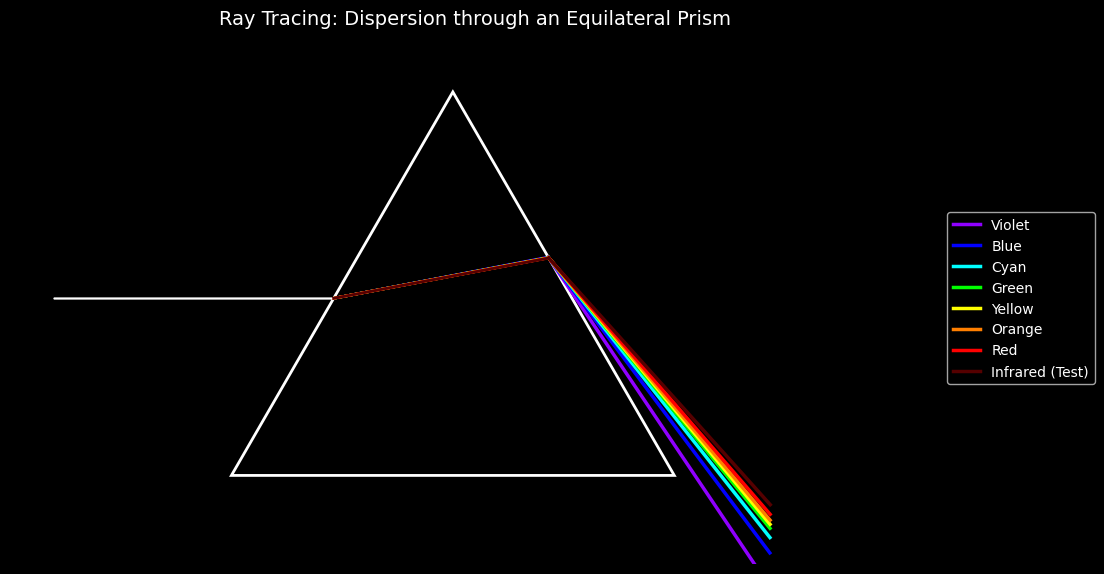

In [33]:
# 3. RAY TRACING LOGIC
# --- 1. PHYSICS CALCULATION LOOP ---
calculated_rays = []

print(f"{'Color':<10} | {'λ (µm)':<8} | {'n(λ)':<8} | {'Exit Angle'}")
print("-" * 48)

for wl, color, name in zip(wavelengths, colors, names):
    n = get_n(wl)
    
    # Physics Calculations
    theta_i1 = np.radians(30)
    theta_r1 = np.arcsin(np.sin(theta_i1) / n)
    theta_i2 = np.radians(60) - theta_r1
    theta_r2 = np.arcsin(n * np.sin(theta_i2))
    exit_angle_deg = np.degrees(theta_r2 - np.radians(30))
    
    print(f"{name:<10} | {wl:<8.2f} | {n:.4f} | {exit_angle_deg:.2f}°")

    # Coordinate Calculations
    p1 = np.array([2.31, 4.0])
    m_ray = np.tan(np.radians(30) - theta_r1)
    x2 = (17.32 - (p1[1] - m_ray * p1[0])) / (1.732 + m_ray)
    y2 = m_ray * (x2 - p1[0]) + p1[1]
    p2 = np.array([x2, y2])
    
    m_out = np.tan(-np.radians(exit_angle_deg))
    p3 = p2 + np.array([5, 5 * m_out])

    # Save the data for the next loop
    calculated_rays.append({
        'color': color,
        'name': name,
        'p1': p1,
        'p2': p2,
        'p3': p3
    })

# --- 2. PLOTTING LOOP ---
for ray in calculated_rays:
    # Incoming White Light (p1 is the same for all, but drawn per ray)
    ax.plot([-4, ray['p1'][0]], [4, 4], color='white', lw=1, alpha=0.6) 
    
    # Inside Prism
    ax.plot([ray['p1'][0], ray['p2'][0]], [ray['p1'][1], ray['p2'][1]], 
            color=ray['color'], lw=2)    
    
    # Exit Ray
    ax.plot([ray['p2'][0], ray['p3'][0]], [ray['p2'][1], ray['p3'][1]], 
            color=ray['color'], lw=2.5, label=ray['name'])
    
# 4. formatting
ax.set_aspect('equal')
ax.set_xlim(-5, 16)
ax.set_ylim(-2, 10)
ax.axis('off') 
plt.title("Ray Tracing: Dispersion through an Equilateral Prism", color='white', fontsize=14)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), facecolor='black', labelcolor='white')


# 5. saving the figure
folder_name = "figures"
if not os.path.exists(folder_name):
    os.makedirs(folder_name)

file_path = os.path.join(folder_name, "prism_dispersion.png")


fig.savefig(file_path, 
            bbox_inches='tight', 
            dpi=300, 
            facecolor=fig.get_facecolor(), 
            edgecolor='none')

print(f"\nSuccess! Figure saved to: {file_path}")

# Display in Jupyter
plt.show()

# Conclusion

The *Dark Side of the Moon* album cover is not physically accurate, as demonstrated by the ray tracing model above. 

The Discrepancy: The album cover depicts each wavelength of light with equally spaced (linear) trajectories after exiting the prism. 
The Physics: In reality, the index of refraction is not linearly dependent on the wavelength. According to **Cauchy's Equation**:

$$n(\lambda) = A + \frac{B}{\lambda^2}$$

The Result: Because the index is dependent on the inverse square of the wavelength ($1/\lambda^2$), shorter wavelengths (like violet) experience a disproportionately higher index of refraction. This results in significantly increased bending compared to longer wavelengths (like red). 


# AI Usage

Tool used: Google Gemini

How it was used: wrote all Python code. The prompt was initially to incorporate Snell's law, the specific wavelengths, and the refractive index formula from the assignment to create a simple ray-tracing model through a prism with calculated exit angles. Continued to troubleshoot with Gemini to improve the code.

What I changed: I did troubleshooting, refined the code produced by Gemini, and polished the formatting, calculations, and variables to make the flow more coherent. 

How I verified the result: I added two extreme wavelength inputs (UV 0.3µm and IR 1.0µm) to evaluate how the model performed. The model could not generate an exit angle for the UV input, indicating that it correctly predicted TIR. The IR input had the highest exit angle, which aligned with expectations that the longer wavelength would experience the least bending within the prism.  